# DINOv3 Maze Baseline (Frozen Encoder)

This notebook uses a **frozen DINOv3 ViT** encoder and a tiny action head to imitate shortest-path actions
in the maze. The DINO backbone is **not trained**.

We also include a zero-shot greedy policy that uses cosine similarity to the goal embedding (no training at all).

In [1]:
%cd /Users/masha/Documents/visual-reasoning

/Users/masha/Documents/visual-reasoning


In [2]:
import math
import random
from collections import deque
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import timm

/Users/masha/Documents/visual-reasoning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_seed(seed: int = 0) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = get_device()
set_seed(0)
print("Device:", DEVICE)

RUN_FAST = False
IMG_SIZE = 64
MAZE_CELLS = 9

TRAIN_MAZES = 200 if not RUN_FAST else 40
TEST_MAZES = 60 if not RUN_FAST else 10
BATCH_SIZE = 32
EPOCHS = 6 if not RUN_FAST else 2
LR = 1e-3

MAX_STEPS = 200
EVAL_MAZES = 30 if not RUN_FAST else 6

Device: mps


In [4]:
def generate_maze(cells_w: int, cells_h: int, rng: random.Random) -> np.ndarray:
    # Generate a perfect maze with DFS backtracking. Returns grid with 1=wall, 0=free.
    grid = np.ones((cells_h * 2 + 1, cells_w * 2 + 1), dtype=np.uint8)
    visited = np.zeros((cells_h, cells_w), dtype=bool)

    stack = [(0, 0)]
    visited[0, 0] = True
    grid[1, 1] = 0

    while stack:
        x, y = stack[-1]
        neighbors = []
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < cells_w and 0 <= ny < cells_h and not visited[ny, nx]:
                neighbors.append((nx, ny, dx, dy))
        if neighbors:
            nx, ny, dx, dy = rng.choice(neighbors)
            grid[y * 2 + 1 + dy, x * 2 + 1 + dx] = 0
            grid[ny * 2 + 1, nx * 2 + 1] = 0
            visited[ny, nx] = True
            stack.append((nx, ny))
        else:
            stack.pop()

    return grid


def bfs_shortest_path(grid: np.ndarray, start: Tuple[int, int], goal: Tuple[int, int]) -> List[Tuple[int, int]]:
    h, w = grid.shape
    q = deque([start])
    prev = {start: None}

    while q:
        y, x = q.popleft()
        if (y, x) == goal:
            break
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and grid[ny, nx] == 0:
                if (ny, nx) not in prev:
                    prev[(ny, nx)] = (y, x)
                    q.append((ny, nx))

    if goal not in prev:
        return []

    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    path.reverse()
    return path

In [5]:
ACTION_TO_DELTA = {
    0: (-1, 0),  # up
    1: (1, 0),   # down
    2: (0, -1),  # left
    3: (0, 1),   # right
}
DELTA_TO_ACTION = {v: k for k, v in ACTION_TO_DELTA.items()}


def render_state(
    grid: np.ndarray,
    start: Tuple[int, int],
    goal: Tuple[int, int],
    agent: Tuple[int, int],
    img_size: int,
) -> torch.Tensor:
    h, w = grid.shape
    img = np.ones((h, w, 3), dtype=np.float32)
    img[grid == 1] = 0.0

    sy, sx = start
    gy, gx = goal
    ay, ax = agent

    img[sy, sx] = np.array([0.2, 0.9, 0.2], dtype=np.float32)
    img[gy, gx] = np.array([0.2, 0.2, 0.9], dtype=np.float32)
    img[ay, ax] = np.array([0.9, 0.2, 0.2], dtype=np.float32)

    img_t = torch.tensor(img).permute(2, 0, 1).unsqueeze(0)
    img_t = F.interpolate(img_t, size=(img_size, img_size), mode="nearest")
    return img_t.squeeze(0)


def apply_action(
    pos: Tuple[int, int],
    action: int,
    grid: np.ndarray,
) -> Tuple[int, int]:
    dy, dx = ACTION_TO_DELTA[action]
    ny, nx = pos[0] + dy, pos[1] + dx
    if 0 <= ny < grid.shape[0] and 0 <= nx < grid.shape[1] and grid[ny, nx] == 0:
        return (ny, nx)
    return pos


def collect_supervised_samples(n_mazes: int, seed: int) -> Tuple[torch.Tensor, torch.Tensor]:
    rng = random.Random(seed)
    imgs = []
    labels = []

    for _ in range(n_mazes):
        grid = generate_maze(MAZE_CELLS, MAZE_CELLS, rng)
        start = (1, 1)
        goal = (grid.shape[0] - 2, grid.shape[1] - 2)
        path = bfs_shortest_path(grid, start, goal)
        if len(path) < 2:
            continue

        for i in range(len(path) - 1):
            curr = path[i]
            nxt = path[i + 1]
            dy = nxt[0] - curr[0]
            dx = nxt[1] - curr[1]
            action = DELTA_TO_ACTION.get((dy, dx), None)
            if action is None:
                continue

            img = render_state(grid, start, goal, curr, IMG_SIZE)
            imgs.append(img)
            labels.append(action)

    return torch.stack(imgs), torch.tensor(labels, dtype=torch.long)

Train samples: torch.Size([15636, 3, 64, 64]) torch.Size([15636])
Test samples: torch.Size([4592, 3, 64, 64]) torch.Size([4592])


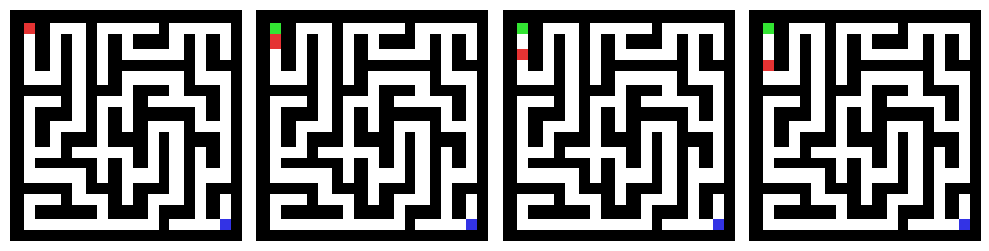

In [6]:
train_imgs, train_y = collect_supervised_samples(TRAIN_MAZES, seed=0)
test_imgs, test_y = collect_supervised_samples(TEST_MAZES, seed=123)

print("Train samples:", train_imgs.shape, train_y.shape)
print("Test samples:", test_imgs.shape, test_y.shape)

# Visualize a few samples
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for ax, i in zip(axes, range(4)):
    img = train_imgs[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
dinov3 = timm.create_model("vit_small_patch16_dinov3", pretrained=True)
dinov3.to(DEVICE)
dinov3.eval()
for p in dinov3.parameters():
    p.requires_grad = False

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)

@torch.no_grad()
def dino_embed(batch_imgs: torch.Tensor) -> torch.Tensor:
    x = batch_imgs.to(DEVICE)
    x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
    x = (x - IMAGENET_MEAN) / IMAGENET_STD

    feats = dinov3.forward_features(x)
    if isinstance(feats, dict):
        if "x_norm_clstoken" in feats:
            feats = feats["x_norm_clstoken"]
        elif "x" in feats:
            feats = feats["x"]

    if feats.dim() == 3:
        feats = feats[:, 0, :]
    return feats

In [8]:
def embed_dataset(imgs: torch.Tensor, batch_size: int = 32) -> torch.Tensor:
    feats = []
    for i in range(0, len(imgs), batch_size):
        batch = imgs[i:i + batch_size]
        feats.append(dino_embed(batch).cpu())
    return torch.cat(feats, dim=0)

train_feats = embed_dataset(train_imgs, batch_size=BATCH_SIZE)
test_feats = embed_dataset(test_imgs, batch_size=BATCH_SIZE)

print("Train feats:", train_feats.shape)
print("Test feats:", test_feats.shape)

Train feats: torch.Size([15636, 384])
Test feats: torch.Size([4592, 384])


In [9]:
feat_dim = train_feats.shape[1]

head = nn.Sequential(
    nn.LayerNorm(feat_dim),
    nn.Linear(feat_dim, 128),
    nn.ReLU(inplace=True),
    nn.Linear(128, 4),
).to(DEVICE)

optimizer = torch.optim.Adam(head.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_loader = DataLoader(
    TensorDataset(train_feats, train_y),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

for epoch in range(EPOCHS):
    head.train()
    total_loss = 0.0
    for feats, y in train_loader:
        feats = feats.to(DEVICE)
        y = y.to(DEVICE)

        logits = head(feats)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}/{EPOCHS} - loss: {avg_loss:.4f}")

Epoch 1/6 - loss: 1.2624
Epoch 2/6 - loss: 1.2126
Epoch 3/6 - loss: 1.1720
Epoch 4/6 - loss: 1.1652
Epoch 5/6 - loss: 1.1608
Epoch 6/6 - loss: 1.1603


In [10]:
head.eval()
with torch.no_grad():
    logits = head(test_feats.to(DEVICE))
    preds = logits.argmax(dim=1).cpu()

acc = (preds == test_y).float().mean().item()
print(f"Test action accuracy: {acc:.3f}")

Test action accuracy: 0.497


In [11]:
@torch.no_grad()
def rollout_linear_policy(n_episodes: int, seed: int = 0):
    rng = random.Random(seed)
    successes = 0
    lengths = []

    for _ in range(n_episodes):
        grid = generate_maze(MAZE_CELLS, MAZE_CELLS, rng)
        start = (1, 1)
        goal = (grid.shape[0] - 2, grid.shape[1] - 2)
        pos = start

        for step in range(MAX_STEPS):
            if pos == goal:
                successes += 1
                lengths.append(step)
                break

            img = render_state(grid, start, goal, pos, IMG_SIZE)
            feat = dino_embed(img.unsqueeze(0))
            logits = head(feat).squeeze(0)

            # pick best valid action
            for a in torch.argsort(logits, descending=True).tolist():
                new_pos = apply_action(pos, a, grid)
                if new_pos != pos:
                    pos = new_pos
                    break
        else:
            lengths.append(MAX_STEPS)

    success_rate = successes / n_episodes
    avg_len = sum(lengths) / len(lengths)
    return success_rate, avg_len


@torch.no_grad()
def rollout_zeroshot_policy(n_episodes: int, seed: int = 0):
    rng = random.Random(seed)
    successes = 0
    lengths = []

    for _ in range(n_episodes):
        grid = generate_maze(MAZE_CELLS, MAZE_CELLS, rng)
        start = (1, 1)
        goal = (grid.shape[0] - 2, grid.shape[1] - 2)
        pos = start

        goal_img = render_state(grid, start, goal, goal, IMG_SIZE)
        goal_feat = dino_embed(goal_img.unsqueeze(0))

        for step in range(MAX_STEPS):
            if pos == goal:
                successes += 1
                lengths.append(step)
                break

            best_sim = -1e9
            best_action = 0
            for a in range(4):
                new_pos = apply_action(pos, a, grid)
                if new_pos == pos:
                    continue
                cand_img = render_state(grid, start, goal, new_pos, IMG_SIZE)
                cand_feat = dino_embed(cand_img.unsqueeze(0))
                sim = F.cosine_similarity(cand_feat, goal_feat).item()
                if sim > best_sim:
                    best_sim = sim
                    best_action = a

            pos = apply_action(pos, best_action, grid)
        else:
            lengths.append(MAX_STEPS)

    success_rate = successes / n_episodes
    avg_len = sum(lengths) / len(lengths)
    return success_rate, avg_len


lin_succ, lin_len = rollout_linear_policy(EVAL_MAZES, seed=1)
zs_succ, zs_len = rollout_zeroshot_policy(EVAL_MAZES, seed=1)

print(f"Linear head policy: success={lin_succ:.2f}, avg_steps={lin_len:.1f}")
print(f"Zero-shot policy:   success={zs_succ:.2f}, avg_steps={zs_len:.1f}")

Linear head policy: success=0.00, avg_steps=200.0
Zero-shot policy:   success=0.00, avg_steps=200.0


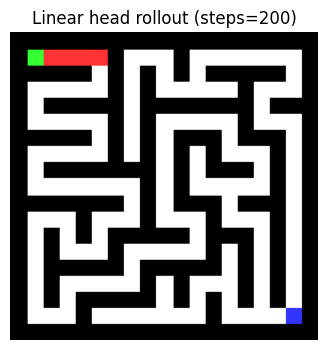

In [12]:
@torch.no_grad()
def rollout_linear_once(seed: int = 42):
    rng = random.Random(seed)
    grid = generate_maze(MAZE_CELLS, MAZE_CELLS, rng)
    start = (1, 1)
    goal = (grid.shape[0] - 2, grid.shape[1] - 2)
    pos = start
    path = [pos]

    for _ in range(MAX_STEPS):
        if pos == goal:
            break
        img = render_state(grid, start, goal, pos, IMG_SIZE)
        feat = dino_embed(img.unsqueeze(0))
        logits = head(feat).squeeze(0)
        for a in torch.argsort(logits, descending=True).tolist():
            new_pos = apply_action(pos, a, grid)
            if new_pos != pos:
                pos = new_pos
                path.append(pos)
                break

    return grid, start, goal, path


def render_path(grid, start, goal, path, img_size=192):
    h, w = grid.shape
    img = np.ones((h, w, 3), dtype=np.float32)
    img[grid == 1] = 0.0

    for y, x in path:
        img[y, x] = np.array([1.0, 0.2, 0.2], dtype=np.float32)

    sy, sx = start
    gy, gx = goal
    img[sy, sx] = np.array([0.2, 1.0, 0.2], dtype=np.float32)
    img[gy, gx] = np.array([0.2, 0.2, 1.0], dtype=np.float32)

    img_t = torch.tensor(img).permute(2, 0, 1).unsqueeze(0)
    img_t = F.interpolate(img_t, size=(img_size, img_size), mode="nearest").squeeze(0)
    return img_t.permute(1, 2, 0).numpy()


grid, start, goal, path = rollout_linear_once()
plt.figure(figsize=(4, 4))
plt.imshow(render_path(grid, start, goal, path))
plt.title(f"Linear head rollout (steps={len(path) - 1})")
plt.axis("off")
plt.show()